In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import polars as pl
import statsmodels.api as sm
from scipy.stats import norm, t

from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from dataclasses import dataclass

**Step 1: Load data from Tardis**

In [802]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

# Set time and exchanges
start_time = datetime.strptime('2025-03-20', '%Y-%m-%d')
end_time = datetime.strptime('2025-03-26', '%Y-%m-%d')
exchange = 'bybit-spot' #'binance-futures'
symbol = 'btcusdt'
                    
# Load the data
trades_df = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_df = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
order_book_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
order_book_10 = order_book_25.select(order_book_25.columns[:45])

# Add Latency Column
trades_df, bbo_df, order_book_25, order_book_10 = [
    ds.with_columns([
        (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
        (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
    ]).filter(pl.col("next_recv_latency").is_not_null())
    for ds in [trades_df, bbo_df, order_book_25, order_book_10]
]

# Take a look at the data
trades_df.describe()

statistic,human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""4682530""","""4682530""","""4682530""",4.68253e6,4.68253e6,4.68253e6,"""4682530""",4.68253e6,4.68253e6,4.68253e6,4.68253e6
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-03-23 14:44:12.056956""",null,null,1.7427e15,1.7427e15,2.2900e18,null,86133.056345,0.011495,46604.961877,46604.961263
"""std""",null,null,null,1.9518e11,1.9518e11,1.3518e6,null,1483.654369,0.056684,46401.786152,46401.786224
"""min""","""2025-03-20 00:00:00.080000""","""bybit-spot""","""BTCUSDT""",1.7424e15,1.7424e15,2.2900e18,"""buy""",83173.0,0.000001,37700.0,37700.0
"""25%""","""2025-03-21 07:50:11.208000""",null,null,1.7425e15,1.7425e15,2.2900e18,null,84581.33,0.000437,39854.0,39854.0
"""50%""","""2025-03-24 04:01:18.342000""",null,null,1.7428e15,1.7428e15,2.2900e18,null,86449.03,0.001708,40698.0,40698.0
"""75%""","""2025-03-25 14:09:42.162000""",null,null,1.7429e15,1.7429e15,2.2900e18,null,87417.0,0.009922,41865.0,41865.0
"""max""","""2025-03-26 23:59:59.441000""","""bybit-spot""","""BTCUSDT""",1.7430e15,1.7430e15,2.2900e18,"""sell""",88773.5,10.086762,2.226729e6,2.226729e6


In [1661]:
trades_df

human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
datetime[μs],str,str,i64,i64,i64,str,f64,f64,i64,i64
2025-03-20 00:00:00.080,"""bybit-spot""","""BTCUSDT""",1742428800080000,1742428800122598,2290000000753507685,"""buy""",86833.58,0.000415,42598,40378
2025-03-20 00:00:00.185,"""bybit-spot""","""BTCUSDT""",1742428800185000,1742428800225378,2290000000753507686,"""buy""",86833.58,0.001051,40378,40378
2025-03-20 00:00:00.185,"""bybit-spot""","""BTCUSDT""",1742428800185000,1742428800225378,2290000000753507687,"""buy""",86833.58,0.005758,40378,40378
2025-03-20 00:00:00.185,"""bybit-spot""","""BTCUSDT""",1742428800185000,1742428800225378,2290000000753507688,"""buy""",86833.85,0.000657,40378,40378
2025-03-20 00:00:00.185,"""bybit-spot""","""BTCUSDT""",1742428800185000,1742428800225378,2290000000753507689,"""buy""",86834.19,0.000696,40378,40378
…,…,…,…,…,…,…,…,…,…,…
2025-03-26 23:59:59.441,"""bybit-spot""","""BTCUSDT""",1743033599441000,1743033599480717,2290000000758190366,"""buy""",86906.2,0.016859,39717,39717
2025-03-26 23:59:59.441,"""bybit-spot""","""BTCUSDT""",1743033599441000,1743033599480717,2290000000758190367,"""buy""",86906.2,0.005754,39717,39717
2025-03-26 23:59:59.441,"""bybit-spot""","""BTCUSDT""",1743033599441000,1743033599480717,2290000000758190368,"""buy""",86906.2,0.000288,39717,39717


In [1665]:
bybit_perp.group_by('local_timestamp').agg(pl.first('exchange').alias('test'))

local_timestamp,test
i64,str
1742776829012183,"""bybit"""
1742521428355493,"""bybit"""
1742877585684033,"""bybit"""
1742512200164805,"""bybit"""
1742891408706957,"""bybit"""
…,…
1742458397853344,"""bybit"""
1742825988153842,"""bybit"""
1742659245824255,"""bybit"""


In [1667]:
bybit_perp

human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
datetime[μs],str,str,i64,i64,str,str,f64,f64,i64,i64
2025-03-19 23:59:59.995,"""bybit""","""BTCUSDT""",1742428799995000,1742428800036887,"""b01dd0bc-0b06-5e01-8de9-74025e…","""buy""",86792.3,0.056,41887,38935
2025-03-20 00:00:00.093,"""bybit""","""BTCUSDT""",1742428800093000,1742428800131935,"""4e53ba7e-8848-5c60-a174-1376d8…","""sell""",86792.2,0.016,38935,38525
2025-03-20 00:00:00.149,"""bybit""","""BTCUSDT""",1742428800149000,1742428800187525,"""4775fe0c-7b6f-5d1d-ac8a-99ac4c…","""sell""",86792.2,0.012,38525,39085
2025-03-20 00:00:00.212,"""bybit""","""BTCUSDT""",1742428800212000,1742428800251085,"""19d5a96d-b62b-583d-854b-495f18…","""sell""",86792.2,0.009,39085,39085
2025-03-20 00:00:00.212,"""bybit""","""BTCUSDT""",1742428800212000,1742428800251085,"""8f78c42e-f68c-51a9-9fb3-7c5e02…","""sell""",86792.2,0.025,39085,39085
…,…,…,…,…,…,…,…,…,…,…
2025-03-26 23:59:58.236,"""bybit""","""BTCUSDT""",1743033598236000,1743033598276234,"""dc5fb979-973c-51e3-85a0-a46de2…","""buy""",86860.0,0.001,40234,40234
2025-03-26 23:59:58.236,"""bybit""","""BTCUSDT""",1743033598236000,1743033598276234,"""6a668876-1540-58d1-9550-a0de9f…","""buy""",86860.0,0.001,40234,40234
2025-03-26 23:59:58.236,"""bybit""","""BTCUSDT""",1743033598236000,1743033598276234,"""3938296e-f71c-582a-a7c0-d648dc…","""buy""",86860.2,0.006,40234,40234


In [800]:
bybit_perp = trades_df

**Step 2: Plot the col distribution, mostly used for calibrate the mapping parameters**

Usage:
1. "rolling_vwap_std" - map 'vwap_std' to 'spread' via a linear function
2. "target_return_normalized" - map 'target_return' to 'feature_skew' via a arctan function

In [15]:
def dist_plot(grouped_df: pl.DataFrame, column: str) -> None:
    # Convert the 'price' column to a Pandas Series for plotting
    price_data = grouped_df[column].to_pandas()

    # Plot histogram
    plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# dist_plot(df, 'rolling_vwap_std')

**Step 3: Group trades and get the single trade feature we need, depends on the exchanges**

**Exchange Details**

1. Bybit: same local timestamp for same bag of trades

**Fixed Window Size Details**

Feature Window = **1000 (10min)**, Vol Window = **200 (2mins)**

In [1542]:
def resample_trades_data(raw_df: pl.DataFrame, price_round: int, volume_round: int, data_span_days: int = 1, exchange: str = 'Bybit', vol_window: int = 200, ) -> pl.DataFrame():
    '''
    Step 1: Resample the raw transcation data into single trade (depends on the rule of exchanges)
    Step 2: Calculate basic features for each single trade, which will be used in aggregation features later
    Step 3: Filter significant trades by volume - to make sure that we always have aroud 100 valid data point per minute
    
    Single Trade Feature: 'vwap', 'volume', 'initial_price'
    Regime Feature (after filter): 'vwap_diff', 'vwap_diff_square'
    '''
    # Feature of single trade (volume, vwap)
    if exchange == 'Bybit':
        grouped_trades = raw_df.group_by("local_timestamp").agg(
            pl.col("human_time").first().alias("human_time"),
            pl.col("timestamp").first().alias("exch_time"),
            pl.col("recv_latency").first().alias("recv_latency"),
            pl.col("price").first().alias("initial_price"),
            pl.col("side").first().alias("side"),
            ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
            pl.col("amount").sum().alias("volume"),
        )
    else:
        raise AttributeError('Only support Bybit for now')
        
    # Round digit for specific columns
    grouped_trades = grouped_trades.with_columns(
        pl.col('vwap').round(price_round).alias('vwap'),
        pl.col('volume').round(volume_round).alias('volume')
    )
    
    # Choose the volume threshold to make that we can have 100 valid trade per minute on average
    min_sample_ratio = (data_span_days * 1440 * 100) / grouped_trades.shape[0] #we need 100 trades per minute
    volume_threshold = grouped_trades.select(pl.col("volume").quantile(1 - min_sample_ratio)).to_numpy()[0][0]
    print(f'volume_threshold: {volume_threshold}')
    
    # Feature of vwap diff between filtered data points - Used for vol calculation
    filter_trades = grouped_trades.lazy().filter(
        pl.col("volume") >= volume_threshold
    ).sort('local_timestamp').with_columns(
        (((pl.col('vwap').diff())/pl.col('vwap')*10000)).alias('vwap_diff'),
        (((pl.col('vwap').diff())/pl.col('vwap')*10000).pow(2)).alias('vwap_diff_square'),
    ).drop_nulls().with_row_index().with_columns(
        pl.mean("vwap_diff_square").rolling(index_column="index", period=f"{vol_window}i").pow(0.5).alias(f'rolling_vwap_std')
    ).collect()
    
    return filter_trades

**Step 4: Calculate aggregation features**

In [1425]:
def agg_feature(grouped_df: pl.DataFrame, feature_window: int, winsorize_features: list[str] = [], winsorize_qtl: float = 0.99) -> pl.DataFrame:
    '''
    Calculate the aggregation features and drop outliers via winsorize
    
    Features: "vwap_diff_sum", "buy_count_ratio", "vwap"
    
    Features that need to be winsorized: ""
    '''
    # Keep the local_timestap as the common column to merge with valid dp in future process
    agg_feature_df = grouped_df.rolling(index_column="index", period=f"{feature_window}i").agg(
        pl.col('local_timestamp').first(),
        pl.col('vwap_diff').filter(pl.col('side') == 'buy').sum().alias('buy_vwap_diff_sum'),
        (pl.col('vwap_diff').filter(pl.col('side') == 'sell').sum() * -1).alias('sell_vwap_diff_sum'),
        (pl.col('side').filter(pl.col('side') == 'buy').count() / feature_window).alias('buy_count_ratio'),
        (pl.col('volume').filter(pl.col('side') == 'buy').sum() / pl.col('volume').sum()).alias('buy_volume_ratio'),
        pl.col('vwap').last().alias('vwap')
    )
    
    # Drop data in the warm-up period
    agg_feature_df = agg_feature_df[feature_window:].fill_nan(0)
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        up_limit = agg_feature_df[feature].quantile(winsorize_qtl)
        agg_feature_df = agg_feature_df.with_columns(
            pl.when(pl.col(feature) >= up_limit).then(up_limit).otherwise(pl.col(feature)).alias(feature),
        )    
    
    return agg_feature_df
    

In [1471]:
def rolling_zscore(agg_df: pl.DataFrame, zscore_window: int = 1000) -> pl.DataFrame:
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their rolling z-score
    '''    
    zscore_df = agg_df.rolling(index_column="index", period=f"{zscore_window}i").agg(
        pl.col('local_timestamp').first(),
        ((pl.col('buy_vwap_diff_sum').last() - pl.col('buy_vwap_diff_sum').mean()) / pl.col('buy_vwap_diff_sum').std()).alias('buy_vd_z'),
        ((pl.col('sell_vwap_diff_sum').last() - pl.col('sell_vwap_diff_sum').mean()) / pl.col('sell_vwap_diff_sum').std()).alias('sell_vd_z'),
        ((pl.col('buy_count_ratio').last() - pl.col('buy_count_ratio').mean()) / pl.col('buy_count_ratio').std()).alias('bcount_z'),
        ((pl.col('buy_volume_ratio').last() - pl.col('buy_volume_ratio').mean()) / pl.col('buy_volume_ratio').std()).alias('bvolume_z'),
        ((pl.col('vwap').last() - pl.col('vwap').mean()) / pl.col('vwap').std()).alias('vwap_z')
    )
    
    # Drop data in the warm-up period
    zscore_df = zscore_df[zscore_window:].fill_nan(0)
    
    return zscore_df

**Step 5: Observation Sampling and Set Target Variable**

In [237]:
def ob_stv(grouped_df: pl.DataFrame, beta_vol: float, fixed_spread: float, blind_spot_ms: int = 10_000, latency_thres: int = 100_000, offset: int = -10_000_000) -> pl.DataFrame:
    '''
    Step 1: Filtering the samples that we care (where we more likely to trade)
    
    Step 2: Set a apropriate target variable - vwap diff between current significant trade and next opposite significant trade 
    
    Step 3: Normalize the target variable with rolling vwap std (which is also required by production)
    
    Step 4: Filter out high latency data points
    '''
    # Step 1: Valid vwap diff should meet such condition: last trade should be the most recent one happened at least 10ms before
    target_df = grouped_df.with_columns(
        pl.last("vwap").rolling(index_column="exch_time", offset=f'{offset}i', period=f'{-blind_spot_ms-offset}i').alias(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')
    ).drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')) / pl.col('vwap') * 10_000).alias(f'valid_vwap_diff')
    )
    
    # Step 2.1: Calculate the spread we will set in production, to filter the significant trade we most care about
    target_df = target_df.with_columns(
        (pl.col("rolling_vwap_std") * beta_vol + fixed_spread).alias('prod_spread')
    ).filter(
        (pl.col('valid_vwap_diff').abs() >= pl.col('prod_spread'))
    )
        
    # Step 2.2: Calculate the target varible: current_vawp - next_opposite_trade_vwap
    target_df = target_df.with_columns(
        (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('bucket_id')
    )
    
    # Step 2.3: Get the next opposite trade vwap
    target_df_2 = target_df.select(
        (pl.col('bucket_id') - 1).alias('bucket_id'),
        pl.col('vwap').alias('vwap')
    ).group_by('bucket_id').agg(
        pl.col('vwap').first().alias('next_trade_price')
    )
    
    # Step 2.4: Merge it back to original df, then we can get our target variable
    target_df = target_df.join(target_df_2, on='bucket_id', how='left').drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
    )
    
    # Step 3: Normalize target variable with rolling vwap std
    target_df = target_df.with_columns(
        (pl.col('target_return_bps') / pl.col('rolling_vwap_std')).alias('target_return_normalized')
    )
    
    # Step 4: Final filter - filter out repetition samples which are too close to each other and high latency samples
    target_df = target_df.filter(
        pl.col('exch_time').diff() >= blind_spot_ms,
        pl.col('recv_latency') <= latency_thres
    )
    
    return target_df

**Step 6: Linear Regression**

In [24]:
def linreg(target_df: pl.DataFrame, feature_df: pl.DataFrame, target: str, feature_list: list[str], merge_col: str ='local_timestamp') -> None:
    '''
    Run the linear regression
    '''
    lr_df = target_df.select(
        pl.col(merge_col),
        pl.col(target)
    ).join(feature_df, on=merge_col, how='left').drop_nulls()
    
    df = lr_df.to_pandas()

    # Define the feature columns and the target column
    X = df[feature_list]  # Feature columns
    y = df[target]  # Target column

    # Add a constant column (intercept) to the feature columns for statsmodels
    X = sm.add_constant(X)

    # Run regression and print result
    model = sm.OLS(y, X).fit()
    print(model.summary())
    
    return lr_df

**Final Step: Hyperparameters**

In [1578]:
@dataclass
class DataProcessParas:
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round: int = 2, 
    volume_round: int = 4, 
    data_span_days: int = 1,
    vol_window: int = 200,
    exchange: str = 'Bybit',
    
    # Step 4: Calculate aggregation features
    feature_window: int = 100, # Aggregation feature window
    winsorize_features: list[str] = [], # List of features that require winsorize on total sample
    winsorize_qtl: float = 0.99,
    zscore_window: int = 1000,
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol: float = 2,
    fixed_spread: float = 0.5,
    blind_spot_ms: int = 10_000, # Assume we can't use the information happened within 10ms from now
    latency_thres: int = 100_000, # 100ms as latency threshold
    
    # Step 6: Linear Regression
    target: str = 'target_return_normalized'
    lr_features: list[str] = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'vwap_z'], # Features that used in linear regression
    merge_col: str = 'local_timestamp' # Col that used to merge target df and feature df

#### Regression Test - 1

In [1645]:
hyper_paras = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 2,
    volume_round = 4,
    data_span_days = 7,
    vol_window = 200,
    exchange = 'Bybit',
    
    # Step 4: Calculate aggregation features
    feature_window = 50,
    winsorize_features = [],
    winsorize_qtl = 0.99,
    zscore_window = 200,
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol = 2,
    fixed_spread = 0.5,
    blind_spot_ms = 20_000,
    latency_thres = 100_000,
    
    # Step 6: Linear Regression
    target = 'target_return_normalized',
    lr_features = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'bvolume_z', 'vwap_z'], #['buy_vd_z', , , , ],
    merge_col = 'local_timestamp'
)

volume_threshold: 0.001


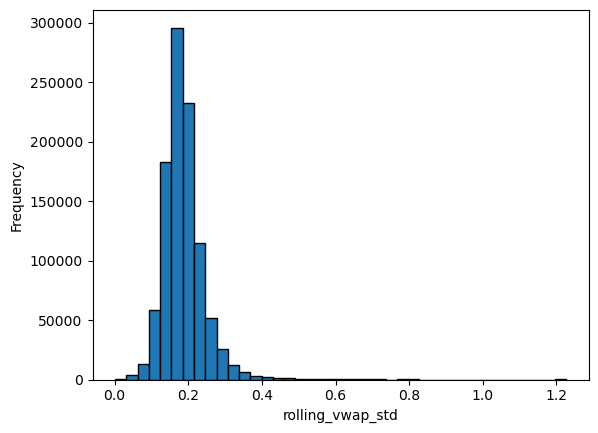

In [1647]:
grouped_df = resample_trades_data(trades_df, hyper_paras.price_round, hyper_paras.volume_round, hyper_paras.data_span_days, hyper_paras.exchange, hyper_paras.vol_window)
dist_plot(grouped_df, 'rolling_vwap_std')

In [1648]:
feature_df = agg_feature(grouped_df, hyper_paras.feature_window, hyper_paras.winsorize_features, hyper_paras.winsorize_qtl)
zscore_df = rolling_zscore(feature_df, hyper_paras.zscore_window)

# Doing clipping
for feature in zscore_df.columns[2:]:
    upper_limit = 3
    lower_limit = -3
    zscore_df = zscore_df.with_columns(
        pl.when(pl.col(feature) >= upper_limit).then(upper_limit)
        .when(pl.col(feature) <= lower_limit).then(lower_limit)
        .otherwise(pl.col(feature)).alias(feature),
    )

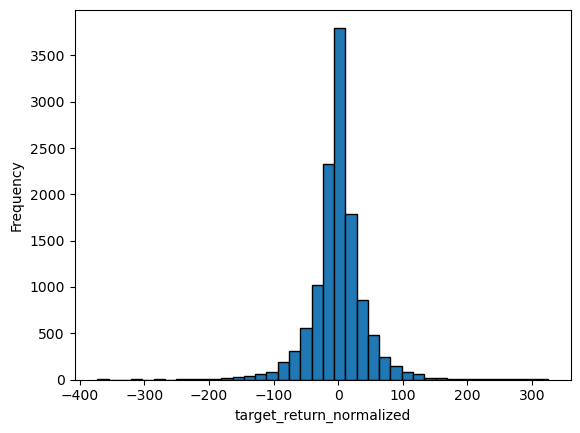

In [1649]:
target_df = ob_stv(grouped_df, hyper_paras.beta_vol, hyper_paras.fixed_spread, hyper_paras.blind_spot_ms, hyper_paras.latency_thres)
dist_plot(target_df, hyper_paras.target)

In [1657]:
zscore_df

index,local_timestamp,buy_vd_z,sell_vd_z,bcount_z,bvolume_z,vwap_z
u32,i64,f64,f64,f64,f64,f64
250,1742428800996300,2.031146,0.186664,0.009462,0.795183,0.058794
251,1742428800997247,2.015477,-0.191167,0.014227,0.945616,0.360026
252,1742428801024202,1.997637,-0.299573,0.019013,0.927702,0.336878
253,1742428801168471,1.900344,-0.333918,0.128577,0.927155,0.271349
254,1742428801845049,1.915578,-0.336635,0.13194,0.910575,0.264986
…,…,…,…,…,…,…
1012359,1743033276502627,3.0,-1.049813,1.287088,1.992199,0.506563
1012360,1743033276503553,2.961711,-1.645593,1.295633,1.915203,0.672974
1012361,1743033276546637,2.896459,-1.658549,1.301161,1.949093,0.68923


In [1659]:
lr_df = linreg(target_df, zscore_df, hyper_paras.target, hyper_paras.lr_features, hyper_paras.merge_col)

                               OLS Regression Results                               
Dep. Variable:     target_return_normalized   R-squared:                       0.175
Model:                                  OLS   Adj. R-squared:                  0.175
Method:                       Least Squares   F-statistic:                     517.7
Date:                      Sun, 06 Apr 2025   Prob (F-statistic):               0.00
Time:                              04:30:30   Log-Likelihood:                -61223.
No. Observations:                     12180   AIC:                         1.225e+05
Df Residuals:                         12174   BIC:                         1.225e+05
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [1574]:
lr_df

local_timestamp,target_return_normalized,index,buy_vd_z,sell_vd_z,bcount_z,bvolume_z,vwap_z
i64,f64,u32,f64,f64,f64,f64,f64
1742470371732270,-25.80552,83480,-1.666698,-1.476616,0.727024,0.800556,-0.401161
1742485623637181,-23.870618,143869,-0.794766,-0.40973,0.642998,-0.607001,1.658157
1742486678471083,21.775932,151247,2.609335,2.441269,1.234017,-0.455014,-2.214765
1742585101129728,28.912556,344439,-0.737611,1.938919,-1.766005,-1.457624,-2.123761
1743016062175303,1.873431,979523,-2.769618,1.758483,-0.065233,-0.412544,-2.281887


#### Download raw data for specific time period

In [ ]:
time = 1742429049008000
btc_trades.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_trades_sample.csv')
btc_ob.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_ob_sample.csv')
btc_bbo.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_bbo_sample.csv')

In [426]:
btc_trades_bn.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{1742429045008000}_btc_trades_sample.csv')